In [20]:
import pandas as pd
import os 
import nltk
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
from nltk import ngrams
from collections import Counter
from matplotlib import pyplot as plt 

counter = Counter

In [81]:
nltk.download('stopwords')

en_stops = stopwords.words('english')[39:]
en_stops.append(',')
en_stops.append('?')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lamda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [82]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')

In [83]:
# dsm_samp = pd.read_csv(os.path.join(data_path, 'dsm_samp_1000.csv'))
dsm_samp = pd.read_csv(os.path.join(data_path, 'dsm_pilot.csv'))
dsm_samp.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,annot
0,t3_5kwodh,depression,Iluvmychildren,"I am not depressed right now, but I say to may...",comment,1.483034e+09,t3_5kwodh,dbrghop,14,0,1
1,5vopn7,depression,derpynarwhal9,I'm twenty five and the earliest I can for sur...,post,1.487830e+09,5vopn7,5vopn7,17,0,0
2,t3_9boomi,depression,Belial42069,This whole subreddit is built around talking b...,comment,1.535674e+09,t3_9boomi,e54l8nt,10,0,3


In [86]:
data = dsm_samp[dsm_samp.label==8]
# data = dsm_samp.copy()
data.reset_index(inplace=True, drop=True)
data.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,annot
0,t3_6ub5fr,depression,tt12345x,Yeah I really envy people that can just peacef...,comment,1.503029e+09,t3_6ub5fr,dlsa1yn,13,8,1
1,7w6ci9,depression,remediosan,Having suicidal thoughts despite life being ha...,post,1.518110e+09,7w6ci9,7w6ci9,31,8,0
2,t3_9y9qtb,depression,AlwaysSnowyInSiberia,But if we don't want to die just yet then we h...,comment,1.542580e+09,t3_9y9qtb,e9zypnp,27,8,1


In [87]:
data.text = data.text.apply(lambda x: x.replace("'m", ' am'))
data.text = data.text.apply(lambda x: x.replace("can't", "can not"))
data.text = data.text.apply(lambda x: x.replace("don't", "do not"))
data.text = data.text.apply(lambda x: x.replace("didn't", "did not"))
data.text = data.text.apply(lambda x: x.replace("doesn't", "does not"))
data.text = data.text.apply(lambda x: x.replace("couldn't", "could not"))
data.text = data.text.apply(lambda x: x.replace("haven't", "have not"))
data.text = data.text.apply(lambda x: x.replace("hasn't", "has not"))
data.text = data.text.apply(lambda x: x.replace("wouldn't", 'would not'))
data.text = data.text.apply(lambda x: x.replace("shouldn't", 'should not'))
data.text = data.text.apply(lambda x: x.replace("'re", " are"))
data.text = data.text.apply(lambda x: x.replace("'s", ' is'))
data.text = data.text.apply(lambda x: x.replace("'ve", ' have'))
data.text = data.text.apply(lambda x: x.replace(",", ' '))
data.text = data.text.apply(lambda x: x.replace("'ll", ' will'))
data.text = data.text.apply(lambda x: x.replace("wasn't", 'was not'))
data.text = data.text.apply(lambda x: x.replace("that's", "that is"))

C:\Users\lamda\AppData\Local\Temp\ipykernel_30504\3417123648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.text = data.text.apply(lambda x: x.replace("'m", ' am'))
C:\Users\lamda\AppData\Local\Temp\ipykernel_30504\3417123648.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.text = data.text.apply(lambda x: x.replace("can't", "can not"))
C:\Users\lamda\AppData\Local\Temp\ipykernel_30504\3417123648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [88]:
group_a = []; group_b = []; group_c = [] 

for idx in range(len(data)):
    if data.annot[idx] == 0:
        group_a.append(word_tokenize(data.text[idx]))
    elif data.annot[idx] == 1:
        group_b.append(word_tokenize(data.text[idx]))
    elif data.annot[idx] == 3:
        group_c.append(word_tokenize(data.text[idx]))

In [89]:
len(list(ngrams(group_a[0], 4))), list(ngrams(group_a[0], 4))

(28,
 [('Having', 'suicidal', 'thoughts', 'despite'),
  ('suicidal', 'thoughts', 'despite', 'life'),
  ('thoughts', 'despite', 'life', 'being'),
  ('despite', 'life', 'being', 'handed'),
  ('life', 'being', 'handed', 'to'),
  ('being', 'handed', 'to', 'me'),
  ('handed', 'to', 'me', 'on'),
  ('to', 'me', 'on', 'a'),
  ('me', 'on', 'a', 'silver'),
  ('on', 'a', 'silver', 'platter'),
  ('a', 'silver', 'platter', 'makes'),
  ('silver', 'platter', 'makes', 'me'),
  ('platter', 'makes', 'me', 'feel'),
  ('makes', 'me', 'feel', 'like'),
  ('me', 'feel', 'like', 'an'),
  ('feel', 'like', 'an', 'even'),
  ('like', 'an', 'even', 'bigger'),
  ('an', 'even', 'bigger', 'piece'),
  ('even', 'bigger', 'piece', 'of'),
  ('bigger', 'piece', 'of', 'shit'),
  ('piece', 'of', 'shit', 'and'),
  ('of', 'shit', 'and', 'that'),
  ('shit', 'and', 'that', 'I'),
  ('and', 'that', 'I', 'dont'),
  ('that', 'I', 'dont', 'deserve'),
  ('I', 'dont', 'deserve', 'any'),
  ('dont', 'deserve', 'any', 'of'),
  ('deserve'

In [90]:
' '.join(list(ngrams(group_a[0], 4))[0]), list(ngrams(group_a[0], 4))[0]

('Having suicidal thoughts despite',
 ('Having', 'suicidal', 'thoughts', 'despite'))

In [91]:
ngram = 4

In [92]:
group_a_ngram = []; group_b_ngram = []; group_c_ngram = [] 

for idx in range(len(group_a)):
    for idx2 in range(len(list(ngrams(group_a[idx], ngram)))):
        group_a_ngram.append(' '.join(list(ngrams(group_a[idx], ngram))[idx2]))
        
for idx in range(len(group_b)):
    for idx2 in range(len(list(ngrams(group_b[idx], ngram)))):
        group_b_ngram.append(' '.join(list(ngrams(group_b[idx], ngram))[idx2]))
        
for idx in range(len(group_c)):
    for idx2 in range(len(list(ngrams(group_c[idx], ngram)))):
        group_c_ngram.append(' '.join(list(ngrams(group_c[idx], ngram))[idx2]))        

In [93]:
len(group_a_ngram), len(group_b_ngram), len(group_c_ngram)

(6427, 5003, 4175)

In [94]:
group_a_ngrams_df = pd.DataFrame(sorted(dict(counter(group_a_ngram)).items(), key = lambda x: x[1], reverse=True), columns=['ngrams', 'cnt'])
group_b_ngrams_df = pd.DataFrame(sorted(dict(counter(group_b_ngram)).items(), key = lambda x: x[1], reverse=True), columns=['ngrams', 'cnt'])
group_c_ngrams_df = pd.DataFrame(sorted(dict(counter(group_c_ngram)).items(), key = lambda x: x[1], reverse=True), columns=['ngrams', 'cnt'])

In [95]:
top_group_a = group_a_ngrams_df.head(5)
top_group_b = group_b_ngrams_df.head(5)
top_group_c = group_c_ngrams_df.head(5)

In [96]:
top_group_a

,ngrams,cnt
0,I want to die,22
1,tried to kill myself,15
2,want to kill myself,14
3,do not want to,9
4,I want to kill,9


In [97]:
top_group = top_group_a.merge(top_group_b, on='ngrams', how='outer')
top_group = top_group.merge(top_group_c, on='ngrams', how='outer')
top_group.fillna(0, inplace=True)
top_group.columns = ['ngrams', 'group_a', 'group_b', 'group_c']
top_group.head(3)

,ngrams,group_a,group_b,group_c
0,I want to die,22.0,0.0,0.0
1,tried to kill myself,15.0,0.0,0.0
2,want to kill myself,14.0,20.0,0.0


In [98]:
top_group

,ngrams,group_a,group_b,group_c
0,I want to die,22.0,0.0,0.0
1,tried to kill myself,15.0,0.0,0.0
2,want to kill myself,14.0,20.0,0.0
3,do not want to,9.0,30.0,0.0
4,I want to kill,9.0,0.0,0.0
5,I do not want,0.0,24.0,3.0
6,I am not suicidal,0.0,16.0,0.0
7,not want to die,0.0,11.0,0.0
8,told me to kill,0.0,0.0,5.0
9,me to kill myself,0.0,0.0,5.0


In [99]:
np.arange(len(top_group))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

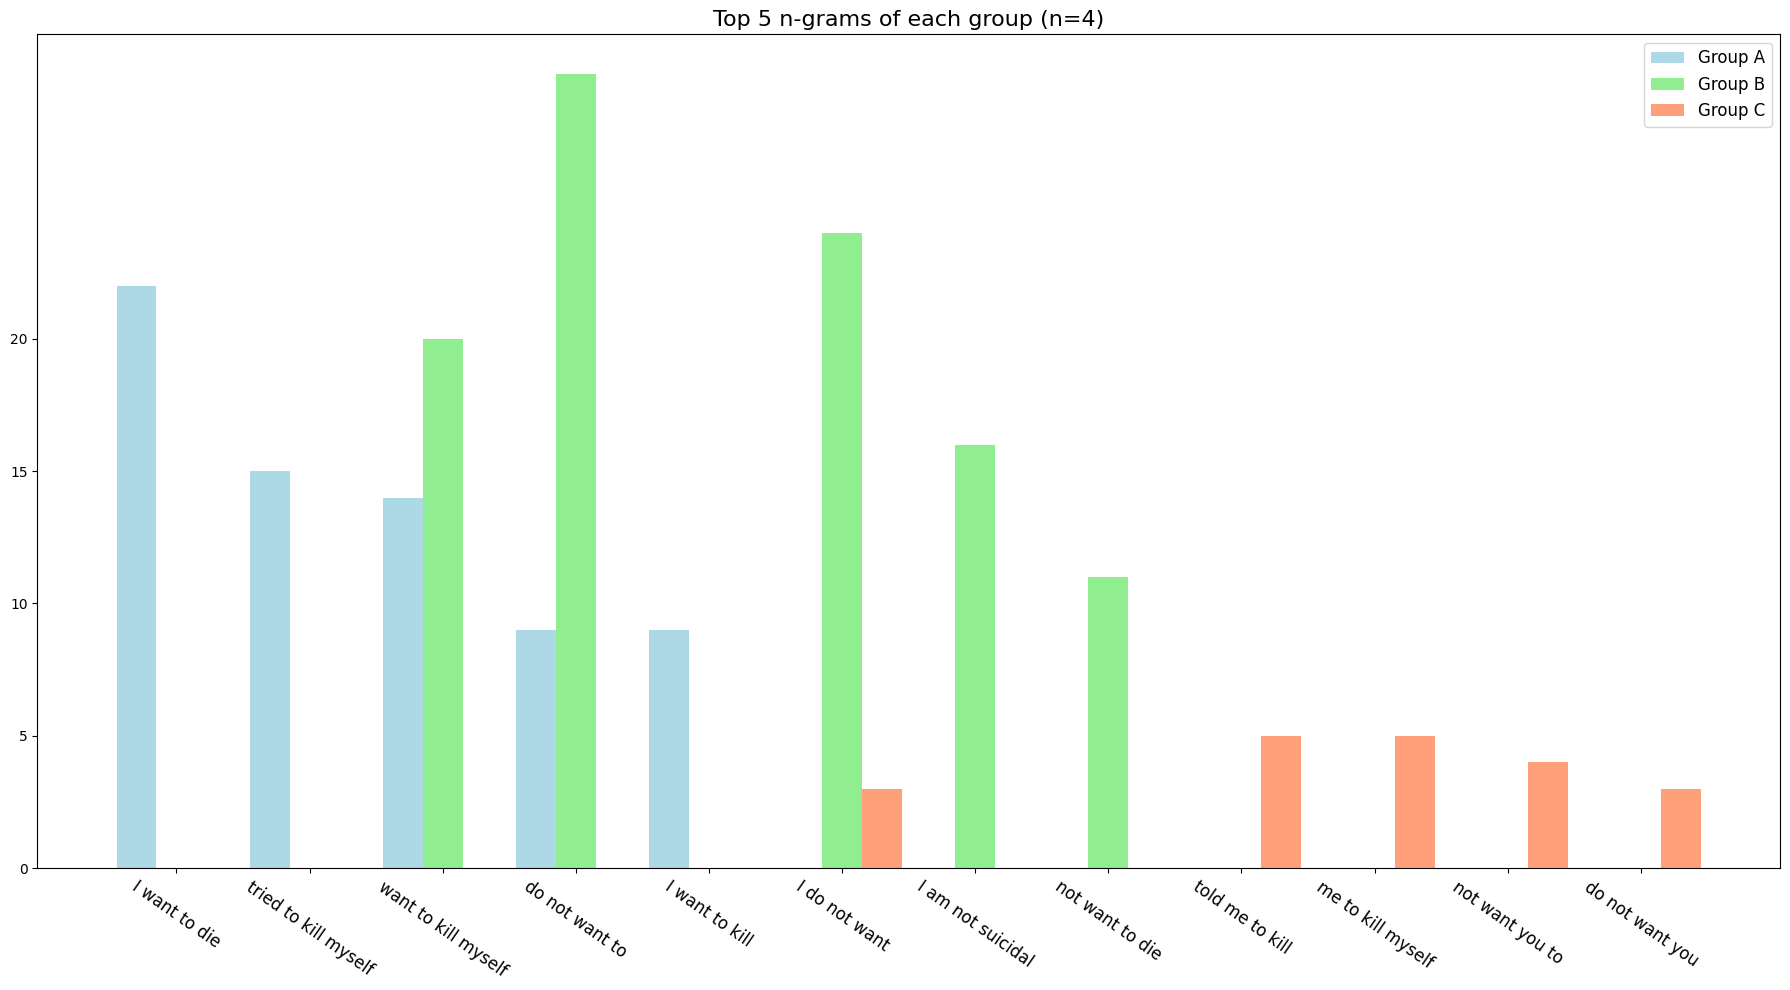

In [100]:
plt.figure(figsize=(18, 10))

index = np.arange(len(top_group))
bar_width = 0.3
plt.bar(index, top_group.group_a, bar_width, color='lightblue', label='Group A')
plt.bar(index + bar_width, top_group.group_b, bar_width, color='lightgreen', label='Group B')
plt.bar(index + bar_width * 2, top_group.group_c, bar_width, color='lightsalmon', label='Group C')
plt.title('Top 5 n-grams of each group (n=4)', fontsize=16)
# plt.xticks(np.arange(len(top_a1_group)), top_a1_group.ngrams, rotation=325, fontsize=12)
plt.yticks([0, 5, 10, 15, 20])
plt.xticks(np.arange(bar_width, len(top_group) + bar_width, 1), top_group.ngrams, rotation=325, fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [681]:
len(group_a_ngram), len(group_b_ngram), len(group_c_ngram)

(6427, 5003, 4175)

In [682]:
len(set(group_a_ngram)), len(set(group_b_ngram)), len(set(group_c_ngram))

(6083, 4696, 4126)

In [683]:
len(group_a_ngrams_df), len(group_b_ngrams_df), len(group_c_ngrams_df)

(6083, 4696, 4126)

In [684]:
len(set(group_a_ngram).intersection(set(group_b_ngram))), len(set(group_b_ngram).intersection(set(group_c_ngram))), len(set(group_a_ngram).intersection(set(group_c_ngram))), len(set(group_a_ngram).intersection(set(group_c_ngram)).intersection(group_b_ngram))

(173, 34, 48, 17)

In [685]:
group_c_ngrams_df[group_c_ngrams_df.ngrams=="cant sleep at night"]

,ngrams,cnt


In [686]:
list(set(group_a_ngram).intersection(set(group_c_ngram)))[:3]

['because I have been', 'was going to die', 'I want to die']

### Total data Filtering

In [687]:
dsm = pd.read_csv(os.path.join(data_path, 'aud_dsm_label2.csv'))
dsm.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label
0,t3_16v6hx,depression,[deleted],if you're lonely i am find an old age pensione...,comment,1.358599e+09,t1_c7zo83f,c7zpy8m,21,0
1,t3_w6zaa,depression,throw13away,One thing that stuck out in my mind from the N...,comment,1.341807e+09,t3_w6zaa,c5bc8t2,27,0
2,t3_95ezhs,depression,pinkwav,"i feel like there's a fine line between ""depre...",comment,1.544300e+09,t1_ebcmg0f,ebdlcmq,15,0


In [690]:
data = dsm[dsm.label==8]
print(f'DSM-5 Criteria A9: {len(data)}')
data.head(3)

DSM-5 Criteria A9: 299534


,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label
1326135,9q1q3e,depression,HopelessRoomful,"I'm pathetic honestly, I'm lucky I'm born as w...",post,1.540107e+09,9q1q3e,9q1q3e,33,8
1326136,efkxj1,depression,[deleted],I cant stop panicking I am terrified my only c...,title,1.577304e+09,efkxj1,efkxj1,16,8
1326137,t3_2c07ad,depression,SoapSamich,"I'm not a likable person but then again, why w...",comment,1.406642e+09,t1_cjap5xu,cjayxme,24,8


In [691]:
data.head(10)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label
1326135,9q1q3e,depression,HopelessRoomful,"I'm pathetic honestly, I'm lucky I'm born as w...",post,1.540107e+09,9q1q3e,9q1q3e,33,8
1326136,efkxj1,depression,[deleted],I cant stop panicking I am terrified my only c...,title,1.577304e+09,efkxj1,efkxj1,16,8
1326137,t3_2c07ad,depression,SoapSamich,"I'm not a likable person but then again, why w...",comment,1.406642e+09,t1_cjap5xu,cjayxme,24,8
1326138,t3_a4bgad,depression,Bogus234e,"I eventually realized I wasn't suicidal, but O...",comment,1.544299e+09,t3_a4bgad,ebdl3mm,19,8
1326139,t3_5fgd70,depression,Gracie_Dee_,"I don't want to die, but living is hell",comment,1.480536e+09,t3_5fgd70,damidkl,11,8
1326140,t3_7up6ht,depression,Billybeanist,After I tried to kill myself and was laying in...,comment,1.517557e+09,t1_dtm3td0,dtm6s3n,31,8
1326141,t3_98zrjz,depression,hustlexLX,"I will be honest, I want to die, but I dont wa...",comment,1.534863e+09,t3_98zrjz,e4knlbp,18,8
1326142,t3_47k6hi,depression,JacquesPL1980,It's a wonder we aren't all depressed and suic...,comment,1.456442e+09,t1_d0dn9u8,d0dw87q,11,8
1326143,t3_4lul4z,depression,Sjatar,Would die to get another night like that,comment,1.469142e+09,t1_d5l2mp6,d5lm8l8,8,8
1326144,3hx314,depression,AstralMantis,"""Make it up as fast as you can"" becomes ""keep ...",post,1.440205e+09,3hx314,3hx314,25,8


In [692]:
data.text = data.text.apply(lambda x: x.replace("'m", ' am'))
data.text = data.text.apply(lambda x: x.replace("can't", "can not"))
data.text = data.text.apply(lambda x: x.replace("don't", "do not"))
data.text = data.text.apply(lambda x: x.replace("didn't", "did not"))
data.text = data.text.apply(lambda x: x.replace("doesn't", "does not"))
data.text = data.text.apply(lambda x: x.replace("couldn't", "could not"))
data.text = data.text.apply(lambda x: x.replace("haven't", "have not"))
data.text = data.text.apply(lambda x: x.replace("hasn't", "has not"))
data.text = data.text.apply(lambda x: x.replace("wouldn't", 'would not'))
data.text = data.text.apply(lambda x: x.replace("shouldn't", 'should not'))
data.text = data.text.apply(lambda x: x.replace("'re", " are"))
data.text = data.text.apply(lambda x: x.replace("'s", ' is'))
data.text = data.text.apply(lambda x: x.replace("'ve", ' have'))
data.text = data.text.apply(lambda x: x.replace(",", ' '))
data.text = data.text.apply(lambda x: x.replace("'ll", ' will'))
data.text = data.text.apply(lambda x: x.replace("wasn't", 'was not'))
data.text = data.text.apply(lambda x: x.replace("that's", "that is"))

C:\Users\lamda\AppData\Local\Temp\ipykernel_44760\3417123648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.text = data.text.apply(lambda x: x.replace("'m", ' am'))
C:\Users\lamda\AppData\Local\Temp\ipykernel_44760\3417123648.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.text = data.text.apply(lambda x: x.replace("can't", "can not"))
C:\Users\lamda\AppData\Local\Temp\ipykernel_44760\3417123648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [693]:
group_a_ngrams_df.ngrams.values.tolist()[:3]

['I want to die', 'tried to kill myself', 'want to kill myself']

In [694]:
group_a_ngrams_df.ngrams[337] in "? Im just lonely feeling"

False

In [695]:
def check_ngrams(text, ngrams_list):
    for idx in range(len(ngrams_list)):
        if ngrams_list[idx] in text:
            return True
    return False

In [696]:
group_a_ngrams_list = group_a_ngrams_df.ngrams.values.tolist()

In [697]:
group_b_ngrams_list = group_b_ngrams_df.ngrams.values.tolist()
group_c_ngrams_list = group_c_ngrams_df.ngrams.values.tolist()

In [698]:
group_a_ngrams_list[:10]

['I want to die',
 'tried to kill myself',
 'want to kill myself',
 'do not want to',
 'I want to kill',
 'I tried to kill',
 'I do not want',
 'to kill myself but',
 'I just want to',
 'I am going to']

In [699]:
data['group_a'] = data.text.apply(lambda x: check_ngrams(x, group_a_ngrams_list))
data['group_a']

C:\Users\lamda\AppData\Local\Temp\ipykernel_44760\2347315975.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['group_a'] = data.text.apply(lambda x: check_ngrams(x, group_a_ngrams_list))


1326135    False
1326136     True
1326137    False
1326138    False
1326139     True
           ...  
1625664    False
1625665     True
1625666    False
1625667    False
1625668     True
Name: group_a, Length: 299534, dtype: bool

In [700]:
data['group_b'] = data.text.apply(lambda x: check_ngrams(x, group_b_ngrams_list))

C:\Users\lamda\AppData\Local\Temp\ipykernel_44760\2843693118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['group_b'] = data.text.apply(lambda x: check_ngrams(x, group_b_ngrams_list))


In [701]:
data['group_c'] = data.text.apply(lambda x: check_ngrams(x, group_c_ngrams_list))

C:\Users\lamda\AppData\Local\Temp\ipykernel_44760\347860122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['group_c'] = data.text.apply(lambda x: check_ngrams(x, group_c_ngrams_list))


In [702]:
group_a_idx = data[data.group_a==True].index.tolist()
group_b_idx = data[data.group_b==True].index.tolist()
group_c_idx = data[data.group_c==True].index.tolist()

In [703]:
group_ab_idx = list(set(group_a_idx).intersection(group_b_idx))
group_bc_idx = list(set(group_b_idx).intersection(group_c_idx))
group_ac_idx = list(set(group_a_idx).intersection(group_c_idx))

In [704]:
len(group_a_idx), len(group_b_idx), len(group_c_idx)

(120012, 106658, 61392)

In [705]:
len(group_ab_idx), len(group_bc_idx), len(group_ac_idx)

(83506, 41716, 43223)

In [706]:
group_a_idx2 = [idx for idx in group_a_idx if idx not in group_ab_idx]
only_group_a = [idx for idx in group_a_idx2 if idx not in group_ac_idx]
len(only_group_a)

30339

In [707]:
data.loc[only_group_a]

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
1326136,efkxj1,depression,[deleted],I cant stop panicking I am terrified my only c...,title,1.577304e+09,efkxj1,efkxj1,16,8,True,False,False
1326152,dbmkjx,depression,Wh00pity_sc00p,I mean I guess I could work as a bartender for...,post,1.569897e+09,dbmkjx,dbmkjx,33,8,True,False,False
1326158,9q1y5n,depression,mrblue6,Ive got school on Monday I dont wanna go I j...,post,1.540110e+09,9q1y5n,9q1y5n,23,8,True,False,False
1326159,5owk61,depression,iloveh900,I am at work right now and want to die,title,1.484833e+09,5owk61,5owk61,10,8,True,False,False
1326161,dbmlm0,depression,Piece_Of_Trash_,i can not even kill myself because im a coward,post,1.569897e+09,dbmlm0,dbmlm0,10,8,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625639,bmrqtt,depression,extroverted_inrovert,I know it is selfish so instead of wanting to...,post,1.557449e+09,bmrqtt,bmrqtt,30,8,True,False,False
1625642,41dsox,depression,Purfectkitten,I have a friend who for as long as I have know...,post,1.453042e+09,41dsox,41dsox,26,8,True,False,False
1625644,5ouqbl,depression,[deleted],I do not even have the willpower to kill myself,title,1.484803e+09,5ouqbl,5ouqbl,10,8,True,False,False
1625646,2883m1,depression,zeppelinism,I feel as though I can not do it anymore and y...,post,1.402864e+09,2883m1,2883m1,21,8,True,False,False


In [708]:
group_b_idx2 = [idx for idx in group_b_idx if idx not in group_ab_idx]
only_group_b = [idx for idx in group_b_idx2 if idx not in group_bc_idx]
len(only_group_b)

18492

In [709]:
group_c_idx2 = [idx for idx in group_c_idx if idx not in group_ac_idx]
only_group_c = [idx for idx in group_c_idx2 if idx not in group_bc_idx]
len(only_group_c)

13509

In [710]:
group_a_df = data.loc[only_group_a]
group_a_df.reset_index(inplace=True, drop=True)
print(f'Criteria A3 group a: {len(group_a_df)}')
group_a_df.head()

Criteria A3 group a: 30339


,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,efkxj1,depression,[deleted],I cant stop panicking I am terrified my only c...,title,1.577304e+09,efkxj1,efkxj1,16,8,True,False,False
1,dbmkjx,depression,Wh00pity_sc00p,I mean I guess I could work as a bartender for...,post,1.569897e+09,dbmkjx,dbmkjx,33,8,True,False,False
2,9q1y5n,depression,mrblue6,Ive got school on Monday I dont wanna go I j...,post,1.540110e+09,9q1y5n,9q1y5n,23,8,True,False,False
3,5owk61,depression,iloveh900,I am at work right now and want to die,title,1.484833e+09,5owk61,5owk61,10,8,True,False,False
4,dbmlm0,depression,Piece_Of_Trash_,i can not even kill myself because im a coward,post,1.569897e+09,dbmlm0,dbmlm0,10,8,True,False,False


In [716]:
group_a_df.loc[2].text # .head(30)

'Ive got school on Monday  I dont wanna go  I just wanna die  I wish it was easier'

In [712]:
group_b_df = data.loc[only_group_b]
group_b_df.reset_index(inplace=True, drop=True)
print(f'Criteria A1 (depressed) group b: {len(group_b_df)}')
group_b_df.head()

Criteria A1 (depressed) group b: 18492


,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,5ow5jy,depression,impeccablemix,How do I get the courage to kill myself?,title,1.484827e+09,5ow5jy,5ow5jy,10,8,False,True,False
1,8b7669,depression,nobodiesbody,Why do people think that is going to cure my d...,post,1.523363e+09,8b7669,8b7669,28,8,False,True,False
2,t3_4tay0p,depression,imisstheoldkanye98,If you do not feel suicidal maybe something su...,comment,1.469143e+09,t1_d5g1ie0,d5lmm2y,14,8,False,True,False
3,t3_5frbhp,depression,divarealness,not exactly suicidal but I think about it fai...,comment,1.480537e+09,t3_5frbhp,damj9iu,11,8,False,True,False
4,t3_8imi9l,depression,MrBandit12,That is how I think when I am really suicidal,comment,1.526096e+09,t1_dyuhuql,dyuhvkf,10,8,False,True,False


In [713]:
group_c_df = data.loc[only_group_c]
group_c_df.reset_index(inplace=True, drop=True)
print(f'Criteria A1 (depressed) group c: {len(group_c_df)}')
group_c_df.head()

Criteria A1 (depressed) group c: 13509


,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,t3_3g7vwv,depression,medusaschild,If you have a small bit of growth you could di...,comment,1.439020e+09,t3_3g7vwv,ctvqkk2,32,8,False,False,True
1,t3_16uxyt,depression,[deleted],I even asked someone who I know had problems w...,comment,1.358608e+09,t1_c7zohc0,c7zr3x4,17,8,False,False,True
2,9q25sk,depression,CrimsonViel,And no matter how much anyone says they value ...,post,1.540113e+09,9q25sk,9q25sk,38,8,False,False,True
3,t3_1kxg4n,depression,jules79,I really hope you decide that is what you want...,comment,1.377279e+09,t1_cbtlyie,cbtuq16,30,8,False,False,True
4,t3_47kq56,depression,Laconocal,I just accepted the desire to die,comment,1.456446e+09,t3_47kq56,d0dytxv,7,8,False,False,True


In [714]:
data.to_csv(os.path.join(data_path, 'a9_group.csv'), index=False)
group_a_df.to_csv(os.path.join(data_path, 'a9_group_a.csv'), index=False)
group_b_df.to_csv(os.path.join(data_path, 'a9_group_b.csv'), index=False)
group_c_df.to_csv(os.path.join(data_path, 'a9_group_c.csv'), index=False)

In [715]:
group_a_df

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,efkxj1,depression,[deleted],I cant stop panicking I am terrified my only c...,title,1.577304e+09,efkxj1,efkxj1,16,8,True,False,False
1,dbmkjx,depression,Wh00pity_sc00p,I mean I guess I could work as a bartender for...,post,1.569897e+09,dbmkjx,dbmkjx,33,8,True,False,False
2,9q1y5n,depression,mrblue6,Ive got school on Monday I dont wanna go I j...,post,1.540110e+09,9q1y5n,9q1y5n,23,8,True,False,False
3,5owk61,depression,iloveh900,I am at work right now and want to die,title,1.484833e+09,5owk61,5owk61,10,8,True,False,False
4,dbmlm0,depression,Piece_Of_Trash_,i can not even kill myself because im a coward,post,1.569897e+09,dbmlm0,dbmlm0,10,8,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30334,bmrqtt,depression,extroverted_inrovert,I know it is selfish so instead of wanting to...,post,1.557449e+09,bmrqtt,bmrqtt,30,8,True,False,False
30335,41dsox,depression,Purfectkitten,I have a friend who for as long as I have know...,post,1.453042e+09,41dsox,41dsox,26,8,True,False,False
30336,5ouqbl,depression,[deleted],I do not even have the willpower to kill myself,title,1.484803e+09,5ouqbl,5ouqbl,10,8,True,False,False
30337,2883m1,depression,zeppelinism,I feel as though I can not do it anymore and y...,post,1.402864e+09,2883m1,2883m1,21,8,True,False,False


In [564]:
group_c_df.loc[100].text

'How do you cope with constant tiredness lack of energy?'